# NAND THAKOR_TASK 2

# Unemployment Analysis with Python

### Importing Libraries

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

### Loading Dataset

In [159]:
df=pd.read_csv("Unemployment in India.csv")

### Understanding Dataset

In [160]:
df.shape

(768, 7)

In [161]:
df.head(5)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [162]:
df.tail(50)
df.sample(5)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
402,Bihar,30-06-2019,Monthly,13.29,3248864.0,39.35,Urban
320,Uttar Pradesh,31-07-2019,Monthly,9.19,42697000.0,38.78,Rural
617,Puducherry,30-06-2019,Monthly,0.00,304369.0,37.73,Urban
80,Gujarat,31-05-2019,Monthly,2.88,13954728.0,52.03,Rural
725,Uttar Pradesh,30-06-2020,Monthly,13.05,13208724.0,38.09,Urban


In [163]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


### Data Cleaning and Preprocessing

##### Checking Missing Values

In [165]:
df.isnull().count()

Region                                      768
 Date                                       768
 Frequency                                  768
 Estimated Unemployment Rate (%)            768
 Estimated Employed                         768
 Estimated Labour Participation Rate (%)    768
Area                                        768
dtype: int64

In [166]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [167]:
df.columns = df.columns.str.strip()

##### Converting Date Column into Datetime Format

In [168]:
df["Date"] = df["Date"].str.strip()
df["Date"] = pd.to_datetime(df["Date"],format="%d-%m-%Y")

In [169]:
df["Date"]

0     2019-05-31
1     2019-06-30
2     2019-07-31
3     2019-08-31
4     2019-09-30
         ...    
763          NaT
764          NaT
765          NaT
766          NaT
767          NaT
Name: Date, Length: 768, dtype: datetime64[ns]

## Exploratory Data Analysis 

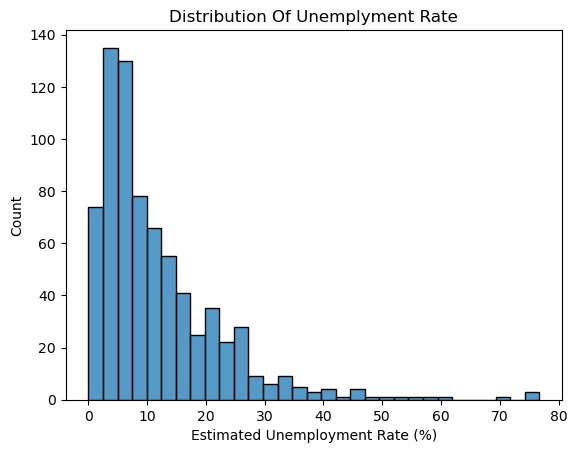

In [170]:
sns.histplot(df["Estimated Unemployment Rate (%)"])
plt.title("Distribution Of Unemplyment Rate")
plt.show()

##### Region-wise Unemployment Analysis

In [171]:
a_unemployment=df.groupby("Region")["Estimated Unemployment Rate (%)"].mean()
a_unemplpyment=a_unemployment.sort_values(ascending=False)
print(a_unemployment)

Region
Andhra Pradesh       7.477143
Assam                6.428077
Bihar               18.918214
Chandigarh          15.991667
Chhattisgarh         9.240357
Delhi               16.495357
Goa                  9.274167
Gujarat              6.663929
Haryana             26.283214
Himachal Pradesh    18.540357
Jammu & Kashmir     16.188571
Jharkhand           20.585000
Karnataka            6.676071
Kerala              10.123929
Madhya Pradesh       7.406429
Maharashtra          7.557500
Meghalaya            4.798889
Odisha               5.657857
Puducherry          10.215000
Punjab              12.031071
Rajasthan           14.058214
Sikkim               7.249412
Tamil Nadu           9.284286
Telangana            7.737857
Tripura             28.350357
Uttar Pradesh       12.551429
Uttarakhand          6.582963
West Bengal          8.124643
Name: Estimated Unemployment Rate (%), dtype: float64


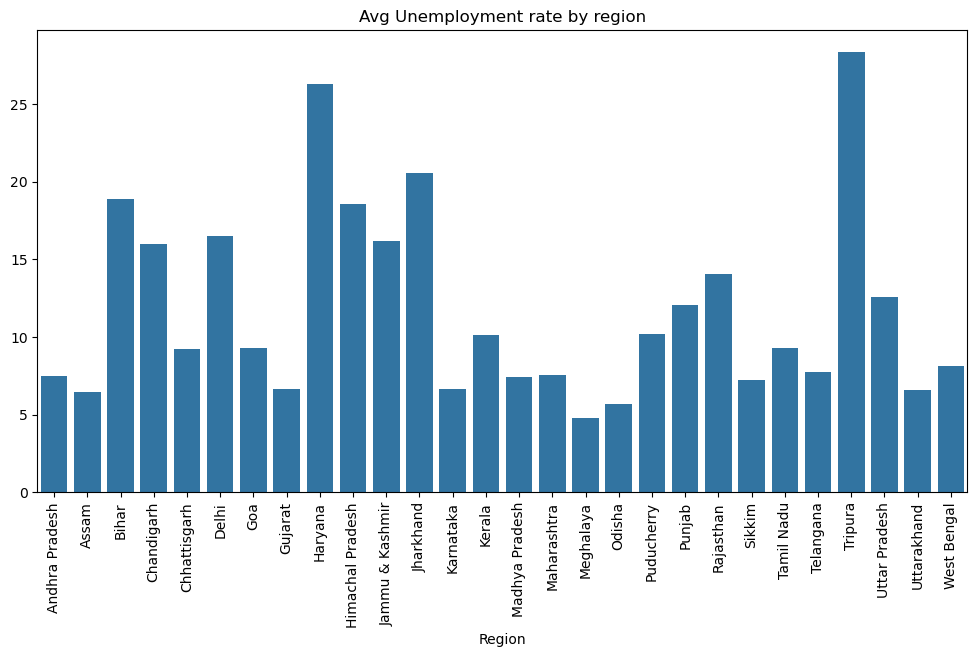

In [172]:
plt.figure(figsize=(12,6))
sns.barplot(x=a_unemployment.index,
            y=a_unemployment.values)
plt.xticks(rotation=90)
plt.title("Avg Unemployment rate by region")
plt.show()


##### Unemployment Trend Over Time

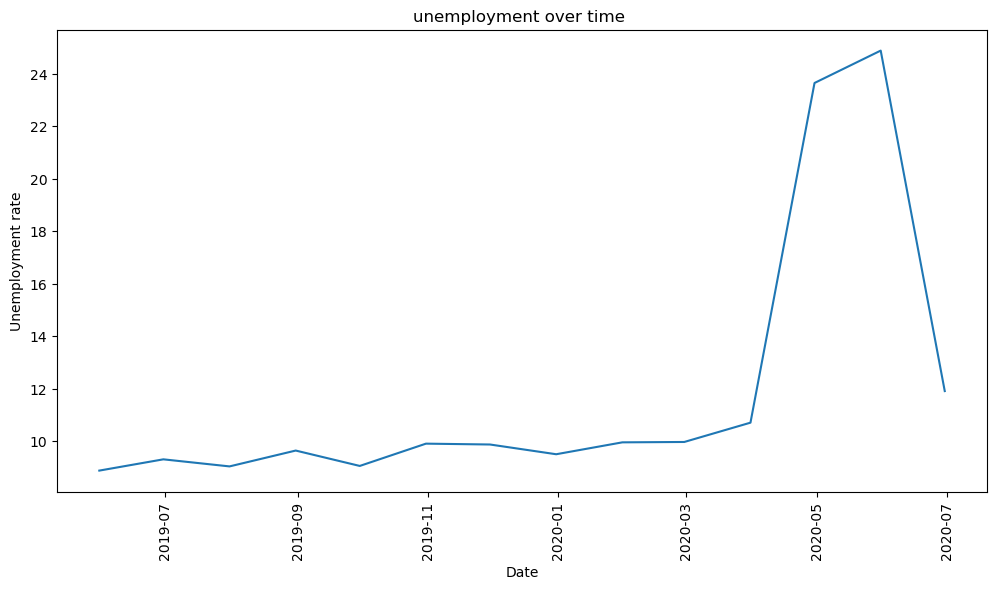

In [173]:
df = df.sort_values(by="Date")
m_unemployment = df.groupby("Date")["Estimated Unemployment Rate (%)"].mean()
plt.figure(figsize=(12,6))
plt.plot(m_unemployment.index,m_unemployment.values)
plt.title("unemployment over time ")
plt.xlabel("Date")
plt.xticks(rotation=90)
plt.ylabel("Unemployment rate")
plt.show()

##### Correlation Analysis

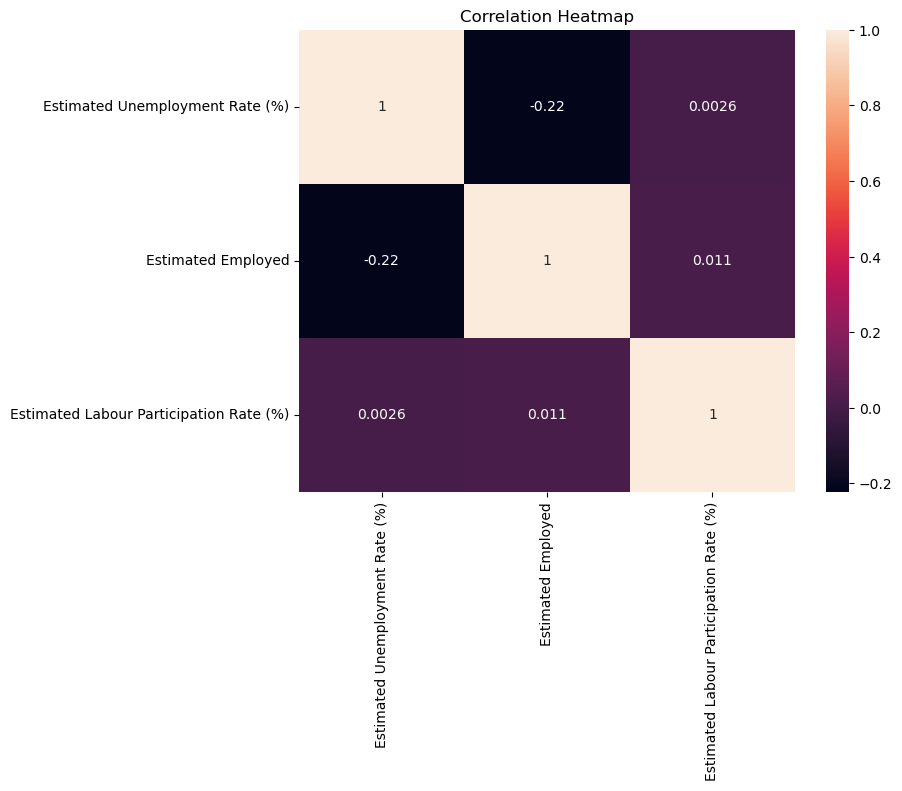

In [174]:
numeric_df=df.select_dtypes(include="number")
correlation = numeric_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(correlation,annot=True)
plt.title("Correlation Heatmap")
plt.show()

##### Covid-19 Impact Analysis

In [175]:
covid_dates = df[(df["Date"]>="2020-03-01") & (df["Date"]<="2020-12-31")]

In [176]:
top_region=covid_dates.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False).head(10)
print(top_region)

Region
Puducherry       38.95500
Jharkhand        36.34875
Haryana          34.65250
Bihar            31.63125
Tripura          26.70250
Tamil Nadu       25.40375
Delhi            22.15750
Kerala           17.95250
Uttar Pradesh    17.38250
Rajasthan        17.31125
Name: Estimated Unemployment Rate (%), dtype: float64


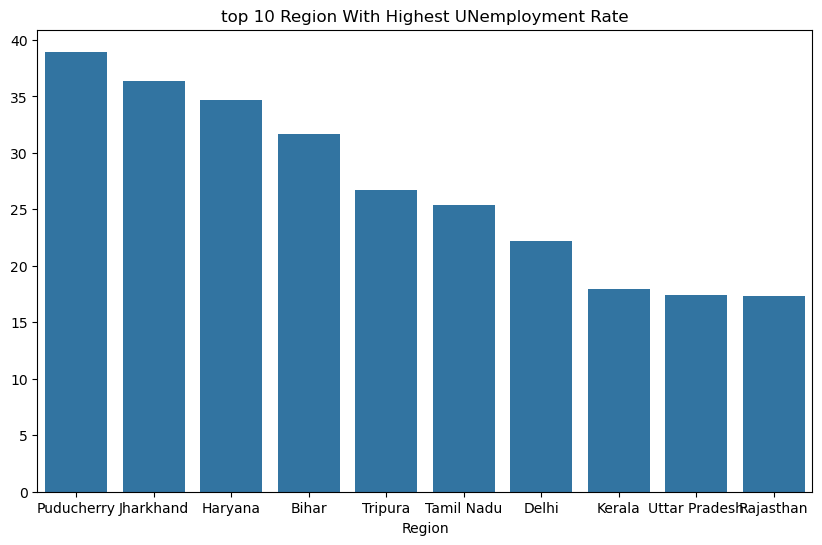

In [177]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_region.index,y=top_region.values)
plt.title("top 10 Region With Highest UNemployment Rate")
plt.show()

##### Monthly Unemployment Analysis

In [178]:
df["Month_Number"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
monthly_avg = df.groupby(["Month_Number", "Month_Name"])["Estimated Unemployment Rate (%)"].mean().reset_index()
monthly_avg = monthly_avg.sort_values("Month_Number")

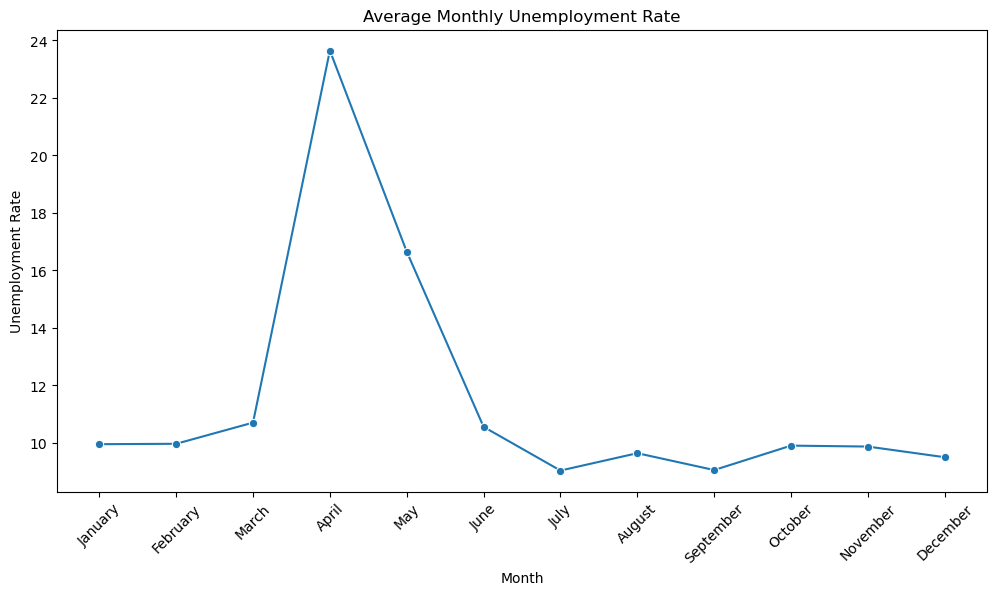

In [179]:
plt.figure(figsize=(12,6))
sns.lineplot(x=monthly_avg["Month_Name"],y=monthly_avg["Estimated Unemployment Rate (%)"],marker="o")
plt.title("Average Monthly Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate")
plt.xticks(rotation=45)
plt.show()

## Conclusion

#### This project analyzed unemployment trends in India during the Covid-19 period using data analysis and visualization techniques.
#### Key observations: 
###### Tripura had the highest average unemployment rate.
###### Unemployment increased sharply between March 2020 and June 2020 due to the Covid-19 lockdown period.
###### After June 2020 unemployment rates gradually decreased showing signs of economic recovery.
###### Monthly and region-wise analysis helped identify the most affected periods and regions.
#### Overall, the project provided practical experience in analyzing real-world unemployment data using Python.